<a href="https://colab.research.google.com/github/melia1702/Pertemuan-kelima/blob/main/Praktikum_5_2_MG_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


PRAKTIKUM 5.2: PERBANDINGAN FILTER LINEAR


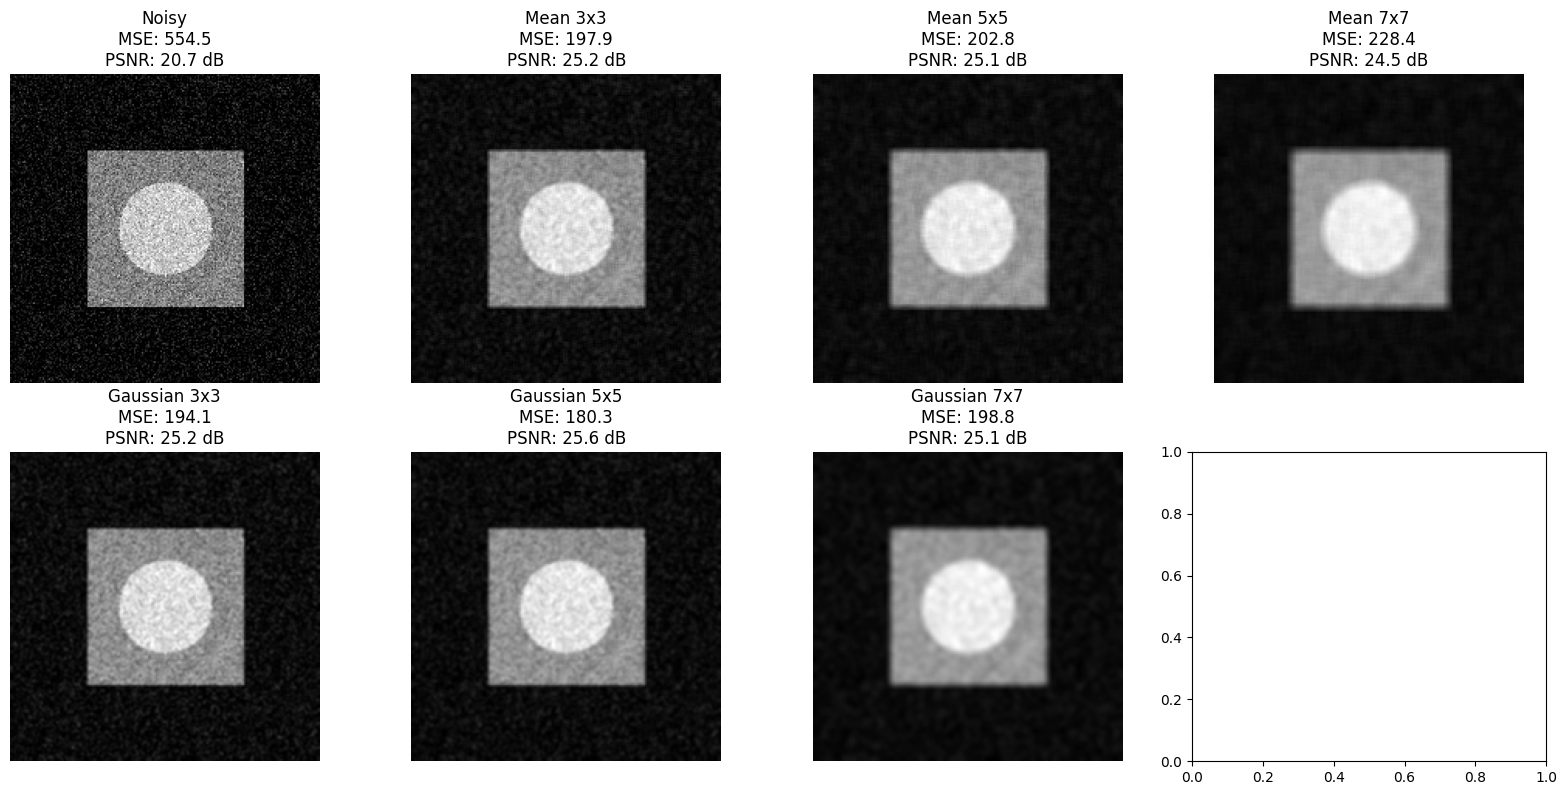


PERFORMANCE COMPARISON OF LINEAR FILTERS
------------------------------------------------------------
Filter          MSE          PSNR (dB)   
------------------------------------------------------------
Noisy           554.50       20.69       
Mean 3x3        197.90       25.17       
Mean 5x5        202.84       25.06       
Mean 7x7        228.36       24.54       
Gaussian 3x3    194.13       25.25       
Gaussian 5x5    180.31       25.57       
Gaussian 7x7    198.85       25.15       


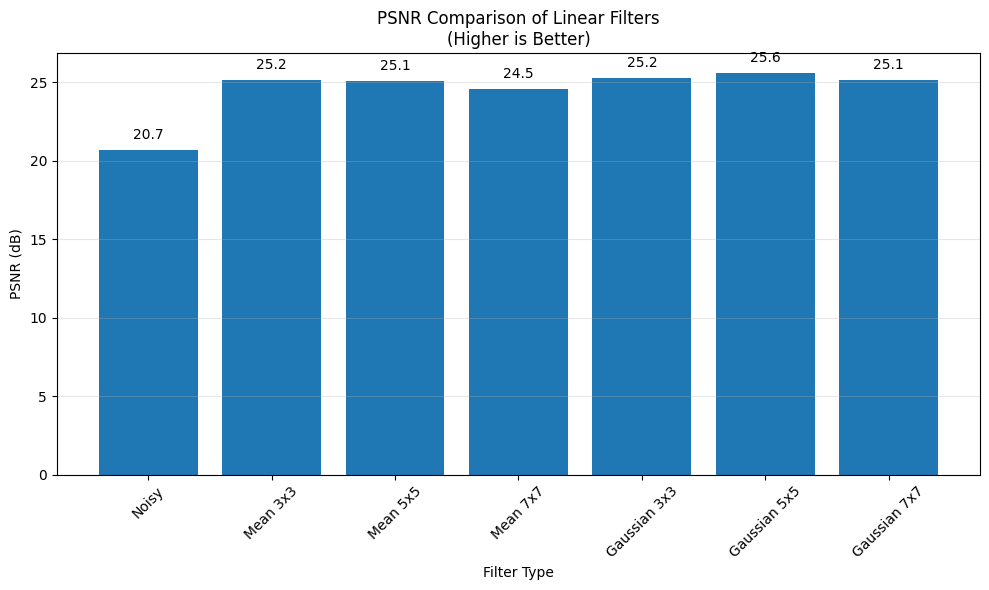

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def compare_linear_filters():
    """
    Perbandingan performa berbagai filter linear
    """
    print("\nPRAKTIKUM 5.2: PERBANDINGAN FILTER LINEAR")
    print("=" * 50)

    # Create noisy image
    clean_img = np.zeros((200, 200), dtype=np.uint8)
    cv2.rectangle(clean_img, (50, 50), (150, 150), 128, -1)
    cv2.circle(clean_img, (100, 100), 30, 200, -1)

    # Add Gaussian noise
    noise = np.random.normal(0, 30, clean_img.shape)
    noisy_img = np.clip(clean_img.astype(float) + noise, 0, 255).astype(np.uint8)

    # Apply different linear filters
    filters = {
        'Noisy': lambda x: x,
        'Mean 3x3': lambda x: cv2.blur(x, (3, 3)),
        'Mean 5x5': lambda x: cv2.blur(x, (5, 5)),
        'Mean 7x7': lambda x: cv2.blur(x, (7, 7)),
        'Gaussian 3x3': lambda x: cv2.GaussianBlur(x, (3, 3), 0),
        'Gaussian 5x5': lambda x: cv2.GaussianBlur(x, (5, 5), 1),
        'Gaussian 7x7': lambda x: cv2.GaussianBlur(x, (7, 7), 2)
    }

    # Calculate metrics
    results = []

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    for idx, (filter_name, filter_func) in enumerate(filters.items()):
        filtered_img = filter_func(noisy_img)

        # Calculate metrics
        mse = np.mean((clean_img.astype(float) - filtered_img.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')

        results.append({
            'filter': filter_name,
            'mse': mse,
            'psnr': psnr
        })

        # Display
        axes[idx].imshow(filtered_img, cmap='gray')
        axes[idx].set_title(f'{filter_name}\nMSE: {mse:.1f}\nPSNR: {psnr:.1f} dB')
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    # Display comparison table
    print("\nPERFORMANCE COMPARISON OF LINEAR FILTERS")
    print("-" * 60)
    print(f"{'Filter':<15} {'MSE':<12} {'PSNR (dB)':<12}")
    print("-" * 60)

    for result in results:
        print(f"{result['filter']:<15} {result['mse']:<12.2f} {result['psnr']:<12.2f}")

    # Visual comparison of PSNR
    fig, ax = plt.subplots(figsize=(10, 6))
    filter_names = [r['filter'] for r in results]
    psnr_values = [r['psnr'] for r in results]

    bars = ax.bar(filter_names, psnr_values)
    ax.set_xlabel('Filter Type')
    ax.set_ylabel('PSNR (dB)')
    ax.set_title('PSNR Comparison of Linear Filters\n(Higher is Better)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar, psnr in zip(bars, psnr_values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
               f'{psnr:.1f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    return results

linear_filter_results = compare_linear_filters()